# 🛣️ Vinci Autoroutes — Comparaison exhaustive des algorithmes ML
## Prédiction de la gravité des accidents sur autoroutes (BAAC 2020–2024)

**Objectif :** Identifier le ou les meilleurs algorithmes pour prédire si un accident sera **grave** (hospitalisation/décès) ou **léger**.

**Plan :**
1. Chargement & EDA
2. Feature engineering avancé
3. Baseline — 15 algorithmes comparés
4. Tuning RandomizedSearchCV sur le Top 5
5. Stacking ensemble
6. Analyse des erreurs & feature importance
7. Conclusion

# 1. Chargement & EDA

In [1]:
import sys, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from config import DATA_DIR

df_raw = pd.read_csv(DATA_DIR / "processed_dataset.csv")
print(f"Dataset : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
print(f"Target  : {(df_raw['target']==0).sum():,} légers ({(df_raw['target']==0).mean()*100:.1f}%) | "
      f"{(df_raw['target']==1).sum():,} graves ({(df_raw['target']==1).mean()*100:.1f}%)")
df_raw.head()

Dataset : 69,309 lignes × 25 colonnes
Target  : 33,678 légers (48.6%) | 35,631 graves (51.4%)


,Num_Acc,annee,dep,lat,long,lum,atm,col,circ,nbv,...,catv,mois,jour,heure,saison,catu,sexe,age,secu,target
0,202000000078,2020,40,44.093041,-0.997696,2.0,6.0,6.0,3.0,3.0,...,7.0,2.0,25.0,19.000000,1.0,1.0,1.0,54.0,1.0,1
1,202000000079,2020,33,44.631270,-0.921030,1.0,2.0,7.0,3.0,4.0,...,7.0,3.0,6.0,17.333333,2.0,1.0,1.0,44.0,1.0,1
2,202000000080,2020,62,50.132255,3.107944,2.0,1.0,2.0,1.0,4.0,...,7.0,3.0,8.0,6.750000,2.0,1.0,1.0,30.0,1.0,1
3,202000000080,2020,62,50.132255,3.107944,2.0,1.0,2.0,1.0,4.0,...,7.0,3.0,8.0,6.750000,2.0,2.0,1.0,25.0,1.0,0
4,202000000080,2020,62,50.132255,3.107944,2.0,1.0,2.0,1.0,4.0,...,7.0,3.0,8.0,6.750000,2.0,2.0,1.0,40.0,1.0,0


In [2]:
FEAT = ['lum','atm','col','circ','nbv','prof','surf','infra','situ','vma',
        'catv','mois','jour','heure','saison','catu','sexe','age','secu']

print("Corrélation (Pearson) avec la target :")
corr = df_raw[FEAT + ['target']].corr()['target'].drop('target').sort_values(key=abs, ascending=False)
for f, v in corr.items():
    bar = '█' * int(abs(v) * 60)
    print(f"  {f:10s} {v:+.4f}  {bar}")

Corrélation (Pearson) avec la target :
  secu       -0.2067  ████████████
  sexe       +0.1399  ████████
  catu       +0.0958  █████
  col        +0.0812  ████
  catv       +0.0663  ███
  age        -0.0551  ███
  situ       +0.0372  ██
  vma        -0.0362  ██
  circ       -0.0286  █
  heure      -0.0285  █
  lum        +0.0261  █
  prof       +0.0240  █
  nbv        -0.0205  █
  infra      +0.0149  
  surf       +0.0113  
  jour       +0.0067  
  atm        +0.0022  
  saison     +0.0014  
  mois       -0.0002  


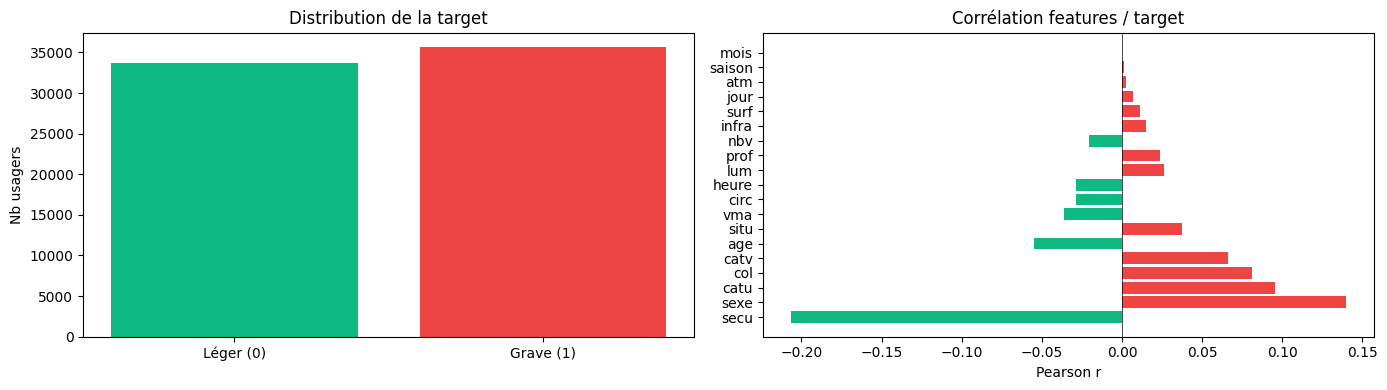

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Distribution target
axes[0].bar(['Léger (0)', 'Grave (1)'],
            [df_raw['target'].value_counts()[0], df_raw['target'].value_counts()[1]],
            color=['#10B981', '#EF4444'])
axes[0].set_title('Distribution de la target')
axes[0].set_ylabel('Nb usagers')

# Taux de gravité par feature clé
axes[1].barh(corr.index, corr.values, color=['#EF4444' if v > 0 else '#10B981' for v in corr.values])
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_title('Corrélation features / target')
axes[1].set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

# 2. Feature Engineering avancé

In [4]:
df = df_raw.copy()

# ── Variables dérivées ──────────────────────────────────────────────────────
# Tranche d'âge (5 groupes)
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 65, 110],
                          labels=[0, 1, 2, 3, 4]).astype(float)

# Conduite de nuit (22h-6h)
df['nuit'] = ((df['heure'] >= 22) | (df['heure'] < 6)).astype(float)

# Mauvaises conditions météo (pluie forte, neige, brouillard, verglas)
df['meteo_adverse'] = df['atm'].isin([3, 4, 5, 6, 7]).astype(float)

# Surface dégradée
df['surf_adverse'] = df['surf'].isin([2, 3, 4, 5, 6, 7, 8]).astype(float)

# Poids lourd (catv: 13=PL, 14=PL+rem, 15=tracteur, 17=autocar)
df['poids_lourd'] = df['catv'].isin([13, 14, 15, 17]).astype(float)

# Collision frontale / latérale (les plus graves)
df['col_grave'] = df['col'].isin([1, 3]).astype(float)

# Interactions
df['nuit_meteo']   = df['nuit'] * df['meteo_adverse']
df['nuit_surf']    = df['nuit'] * df['surf_adverse']
df['secu_age']     = df['secu'] * df['age_group']   # ceinture × âge
df['pl_col_grave'] = df['poids_lourd'] * df['col_grave']

NEW_FEATS = ['age_group','nuit','meteo_adverse','surf_adverse','poids_lourd',
             'col_grave','nuit_meteo','nuit_surf','secu_age','pl_col_grave']

print("Nouvelles features créées :", NEW_FEATS)
print()
print("Corrélation des nouvelles features avec target :")
for f in NEW_FEATS:
    r = df[[f,'target']].dropna().corr().iloc[0,1]
    bar = '█' * int(abs(r) * 80)
    print(f"  {f:15s} {r:+.4f}  {bar}")

Nouvelles features créées : ['age_group', 'nuit', 'meteo_adverse', 'surf_adverse', 'poids_lourd', 'col_grave', 'nuit_meteo', 'nuit_surf', 'secu_age', 'pl_col_grave']

Corrélation des nouvelles features avec target :
  age_group       -0.0633  █████
  nuit            +0.0425  ███
  meteo_adverse   -0.0055  
  surf_adverse    +0.0217  █
  poids_lourd     -0.0001  
  col_grave       +0.0019  
  nuit_meteo      +0.0009  
  nuit_surf       +0.0294  ██
  secu_age        -0.1552  ████████████
  pl_col_grave    -0.0055  


In [5]:
ALL_FEAT = FEAT + NEW_FEATS

# Imputation médiane (conservée pour tous les modèles qui ne gèrent pas NaN)
imputer = SimpleImputer(strategy='median')
X_all = pd.DataFrame(imputer.fit_transform(df[ALL_FEAT]), columns=ALL_FEAT)
y_all = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f"Train : {X_train.shape}   Test : {X_test.shape}")
print(f"Features totales : {len(ALL_FEAT)} ({len(FEAT)} originales + {len(NEW_FEATS)} dérivées)")

Train : (55447, 29)   Test : (13862, 29)
Features totales : 29 (19 originales + 10 dérivées)


# 3. Baseline — 15 algorithmes comparés

In [6]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, AdaBoostClassifier,
                               BaggingClassifier, HistGradientBoostingClassifier,
                               VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

# Scaler pour modèles sensibles à l'échelle
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Subsample pour modèles lents (KNN, SVM)
SUB = 20000
idx_sub = np.random.RandomState(42).choice(len(X_train), SUB, replace=False)
X_sub    = X_train_sc[idx_sub]
y_sub    = y_train[idx_sub]

scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

MODELS = {
    "Logistic Regression":    (LogisticRegression(max_iter=300, random_state=42), X_train_sc, X_test_sc),
    "Ridge Classifier":       (RidgeClassifier(), X_train_sc, X_test_sc),
    "Decision Tree":          (DecisionTreeClassifier(max_depth=10, random_state=42), X_train, X_test),
    "Random Forest":          (RandomForestClassifier(n_estimators=200, max_depth=10,
                                min_samples_leaf=5, random_state=42, n_jobs=-1), X_train, X_test),
    "Extra Trees":            (ExtraTreesClassifier(n_estimators=200, max_depth=12,
                                random_state=42, n_jobs=-1), X_train, X_test),
    "AdaBoost":               (AdaBoostClassifier(n_estimators=100, random_state=42), X_train, X_test),
    "Gradient Boosting":      (GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                learning_rate=0.1, random_state=42), X_train, X_test),
    "HistGradientBoosting":   (HistGradientBoostingClassifier(max_iter=200, max_depth=8,
                                random_state=42), X_train, X_test),
    "XGBoost":                (XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
                                eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0),
                               X_train, X_test),
    "LightGBM":               (lgb.LGBMClassifier(n_estimators=200, max_depth=8, learning_rate=0.05,
                                num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                                scale_pos_weight=scale_pos, random_state=42, n_jobs=-1, verbose=-1),
                               X_train, X_test),
    "KNN (sous-échantillon)": (KNeighborsClassifier(n_neighbors=15, n_jobs=-1), X_sub, X_test_sc),
    "LinearSVC":              (LinearSVC(max_iter=2000, random_state=42), X_train_sc, X_test_sc),
    "Naive Bayes":            (GaussianNB(), X_train_sc, X_test_sc),
    "MLP":                    (MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                random_state=42, early_stopping=True), X_train_sc, X_test_sc),
}
if HAS_CATBOOST:
    MODELS["CatBoost"] = (CatBoostClassifier(iterations=200, depth=8, learning_rate=0.05,
                           random_seed=42, verbose=0, thread_count=-1), X_train, X_test)

print(f"{len(MODELS)} modèles à entraîner...")

15 modèles à entraîner...


In [7]:
results = []
trained_models = {}

for name, (model, Xtr, Xte) in MODELS.items():
    t0 = time.time()
    # KNN utilise son propre sous-ensemble
    if "KNN" in name:
        model.fit(X_sub, y_sub)
    else:
        model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    dur = time.time() - t0

    # predict_proba pour AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(Xte)
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = float('nan')

    row = {
        'Modèle':     name,
        'Accuracy':   accuracy_score(y_test, y_pred),
        'F1':         f1_score(y_test, y_pred, zero_division=0),
        'Précision':  precision_score(y_test, y_pred, zero_division=0),
        'Recall':     recall_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':    auc,
        'Temps (s)':  round(dur, 1),
    }
    results.append(row)
    trained_models[name] = (model, Xte)
    print(f"  ✓ {name:30s}  Acc={row['Accuracy']:.4f}  F1={row['F1']:.4f}  AUC={auc:.4f}  ({dur:.1f}s)")

res_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print()
print(res_df.to_string(index=False))

  ✓ Logistic Regression             Acc=0.6462  F1=0.6463  AUC=0.6814  (0.1s)
  ✓ Ridge Classifier                Acc=0.6451  F1=0.6439  AUC=0.6810  (0.0s)


  ✓ Decision Tree                   Acc=0.6736  F1=0.6790  AUC=0.7284  (0.3s)


  ✓ Random Forest                   Acc=0.6883  F1=0.7041  AUC=0.7465  (2.8s)


  ✓ Extra Trees                     Acc=0.6792  F1=0.6982  AUC=0.7375  (2.6s)


  ✓ AdaBoost                        Acc=0.6659  F1=0.6700  AUC=0.7058  (4.4s)


...

  ✓ LightGBM                        Acc=0.6920  F1=0.6954  AUC=0.7553  (1.3s)


  ✓ KNN (sous-échantillon)          Acc=0.6387  F1=0.6370  AUC=0.6872  (0.9s)


  ✓ LinearSVC                       Acc=0.6452  F1=0.6440  AUC=0.6810  (0.4s)
  ✓ Naive Bayes                     Acc=0.6205  F1=0.5764  AUC=0.6722  (0.1s)


  ✓ MLP                             Acc=0.6783  F1=0.6874  AUC=0.7351  (11.3s)


  ✓ CatBoost                        Acc=0.6881  F1=0.6967  AUC=0.7496  (5.7s)

                Modèle  Accuracy       F1  Précision   Recall  ROC-AUC  Temps (s)
              LightGBM  0.692036 0.695354   0.707420 0.683694 0.755318        1.3
               XGBoost  0.690377 0.692418   0.707528 0.677940 0.750857        1.1
  HistGradientBoosting  0.686553 0.697613   0.691978 0.703340 0.750604        5.2
              CatBoost  0.688068 0.696732   0.696439 0.697025 0.749551        5.7
     Gradient Boosting  0.690016 0.699532   0.697143 0.701937 0.748888       13.7
         Random Forest  0.688285 0.704142   0.687525 0.721583 0.746534        2.8
           Extra Trees  0.679195 0.698202   0.676042 0.721864 0.737533        2.6
                   MLP  0.678257 0.687412   0.686642 0.688184 0.735055       11.3
         Decision Tree  0.673568 0.678964   0.686612 0.671485 0.728406        0.3
              AdaBoost  0.665921 0.669992   0.680614 0.659697 0.705797        4.4
KNN (sous-échantill

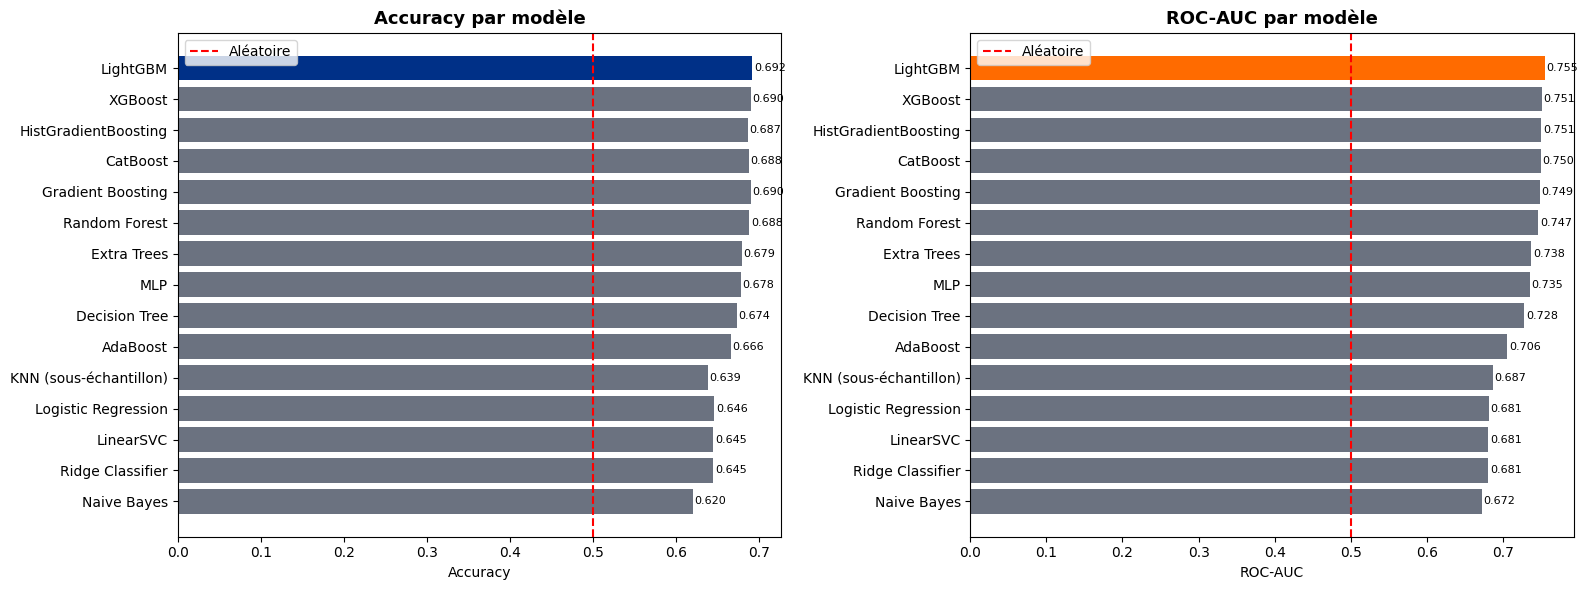

,Modèle,Accuracy,F1,Précision,Recall,ROC-AUC,Temps (s)
0,LightGBM,0.692036,0.695354,0.707420,0.683694,0.755318,1.300000
1,XGBoost,0.690377,0.692418,0.707528,0.677940,0.750857,1.100000
2,HistGradientBoosting,0.686553,0.697613,0.691978,0.703340,0.750604,5.200000
3,CatBoost,0.688068,0.696732,0.696439,0.697025,0.749551,5.700000
4,Gradient Boosting,0.690016,0.699532,0.697143,0.701937,0.748888,13.700000
5,Random Forest,0.688285,0.704142,0.687525,0.721583,0.746534,2.800000
6,Extra Trees,0.679195,0.698202,0.676042,0.721864,0.737533,2.600000
7,MLP,0.678257,0.687412,0.686642,0.688184,0.735055,11.300000
8,Decision Tree,0.673568,0.678964,0.686612,0.671485,0.728406,0.300000
9,AdaBoost,0.665921,0.669992,0.680614,0.659697,0.705797,4.400000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
colors = ['#003087' if i == 0 else '#6B7280' for i in range(len(res_df))]
axes[0].barh(res_df['Modèle'][::-1], res_df['Accuracy'][::-1], color=colors[::-1])
axes[0].axvline(0.5, color='red', linestyle='--', label='Aléatoire')
axes[0].set_title('Accuracy par modèle', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].legend()
for i, v in enumerate(res_df['Accuracy'][::-1]):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

# ROC-AUC
colors2 = ['#FF6B00' if i == 0 else '#6B7280' for i in range(len(res_df))]
axes[1].barh(res_df['Modèle'][::-1], res_df['ROC-AUC'][::-1], color=colors2[::-1])
axes[1].axvline(0.5, color='red', linestyle='--', label='Aléatoire')
axes[1].set_title('ROC-AUC par modèle', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ROC-AUC')
axes[1].legend()
for i, v in enumerate(res_df['ROC-AUC'][::-1]):
    if not np.isnan(v):
        axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()
res_df.style.background_gradient(subset=['Accuracy','F1','ROC-AUC'], cmap='RdYlGn')

# 4. Tuning RandomizedSearchCV — Top 5

In [9]:
# Top 3 seulement — tuning ciblé (cv=3 pour garder un temps raisonnable)
top5_names = res_df.dropna(subset=['ROC-AUC']).head(3)['Modèle'].tolist()
print("Top 3 à tuner :", top5_names)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grids = {
    "XGBoost": {
        'n_estimators':     [200, 300, 400],
        'max_depth':        [4, 6, 8, 10],
        'learning_rate':    [0.03, 0.05, 0.1, 0.15],
        'subsample':        [0.7, 0.8, 0.9],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
        'min_child_weight': [1, 3, 5],
        'gamma':            [0, 0.1, 0.2],
        'reg_alpha':        [0, 0.1, 0.5],
        'reg_lambda':       [1, 1.5, 2],
    },
    "LightGBM": {
        'n_estimators':  [200, 300, 400],
        'max_depth':     [6, 8, 10, -1],
        'learning_rate': [0.03, 0.05, 0.08, 0.1],
        'num_leaves':    [31, 63, 127],
        'subsample':     [0.7, 0.8, 0.9],
        'colsample_bytree': [0.6, 0.7, 0.8],
        'min_child_samples': [10, 20, 30],
        'reg_alpha':     [0, 0.1, 0.5],
        'reg_lambda':    [0, 0.1, 0.5],
    },
    "HistGradientBoosting": {
        'max_iter':        [200, 300, 400],
        'max_depth':       [6, 8, 10, None],
        'learning_rate':   [0.03, 0.05, 0.08, 0.1],
        'max_leaf_nodes':  [31, 63, 127],
        'min_samples_leaf':[10, 20, 30],
        'l2_regularization': [0, 0.1, 0.5, 1.0],
    },
    "Random Forest": {
        'n_estimators':    [200, 300, 400],
        'max_depth':       [8, 10, 12, None],
        'min_samples_leaf':[2, 5, 10],
        'max_features':    ['sqrt', 'log2', 0.3, 0.5],
        'min_samples_split':[2, 5, 10],
    },
    "Extra Trees": {
        'n_estimators':    [200, 300, 400],
        'max_depth':       [10, 12, 15, None],
        'min_samples_leaf':[1, 2, 5],
        'max_features':    ['sqrt', 'log2', 0.3],
    },
    "CatBoost": {
        'iterations':      [200, 300, 400],
        'depth':           [6, 8, 10],
        'learning_rate':   [0.03, 0.05, 0.1],
        'l2_leaf_reg':     [1, 3, 5, 7],
        'border_count':    [32, 64, 128],
    },
}

tuned_results = []
tuned_models  = {}

base_instances = {
    "XGBoost":            XGBClassifier(eval_metric='logloss', random_state=42,
                                         scale_pos_weight=scale_pos, n_jobs=-1, verbosity=0),
    "LightGBM":           lgb.LGBMClassifier(scale_pos_weight=scale_pos, random_state=42,
                                              n_jobs=-1, verbose=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "Random Forest":      RandomForestClassifier(random_state=42, n_jobs=-1),
    "Extra Trees":        ExtraTreesClassifier(random_state=42, n_jobs=-1),
}
if HAS_CATBOOST:
    base_instances["CatBoost"] = CatBoostClassifier(random_seed=42, verbose=0, thread_count=-1)

for name in top5_names:
    if name not in param_grids or name not in base_instances:
        print(f"  ⚠️  {name} — pas de grille définie, skip")
        continue
    print(f"\n🔍 Tuning {name}...")
    t0 = time.time()
    search = RandomizedSearchCV(
        base_instances[name], param_grids[name],
        n_iter=15, cv=cv, scoring='roc_auc',
        n_jobs=-1, random_state=42, verbose=0)
    search.fit(X_train, y_train)
    y_pred = search.best_estimator_.predict(X_test)
    y_prob = search.best_estimator_.predict_proba(X_test)[:, 1]
    dur = time.time() - t0
    row = {
        'Modèle':     f"{name} (tuned)",
        'Accuracy':   accuracy_score(y_test, y_pred),
        'F1':         f1_score(y_test, y_pred, zero_division=0),
        'Précision':  precision_score(y_test, y_pred, zero_division=0),
        'Recall':     recall_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':    roc_auc_score(y_test, y_prob),
        'Temps (s)':  round(dur, 1),
        'Best params': str(search.best_params_),
    }
    tuned_results.append(row)
    tuned_models[name] = search.best_estimator_
    print(f"  ✓ AUC={row['ROC-AUC']:.4f}  Acc={row['Accuracy']:.4f}  ({dur:.0f}s)")
    print(f"    Best : {search.best_params_}")

tuned_df = pd.DataFrame(tuned_results).sort_values('ROC-AUC', ascending=False)
print()
print(tuned_df[['Modèle','Accuracy','F1','ROC-AUC']].to_string(index=False))

Top 3 à tuner : ['LightGBM', 'XGBoost', 'HistGradientBoosting']

🔍 Tuning LightGBM...


  ✓ AUC=0.7550  Acc=0.6935  (66s)
    Best : {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.5, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.6}

🔍 Tuning XGBoost...


  ✓ AUC=0.7568  Acc=0.6962  (35s)
    Best : {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}

🔍 Tuning HistGradientBoosting...


  ✓ AUC=0.7545  Acc=0.6916  (35s)
    Best : {'min_samples_leaf': 10, 'max_leaf_nodes': 127, 'max_iter': 200, 'max_depth': None, 'learning_rate': 0.03, 'l2_regularization': 0}

                      Modèle  Accuracy       F1  ROC-AUC
             XGBoost (tuned)  0.696220 0.697551 0.756805
            LightGBM (tuned)  0.693479 0.695565 0.754961
HistGradientBoosting (tuned)  0.691603 0.700189 0.754510


# 5. Stacking Ensemble

In [10]:
from sklearn.ensemble import StackingClassifier

# Construire le stacking avec les meilleurs modèles tunés
estimators_stack = []
for name in list(tuned_models.keys())[:3]:  # Top 3 tunés
    estimators_stack.append((name.lower().replace(' ','_'), tuned_models[name]))

if len(estimators_stack) >= 2:
    stack = StackingClassifier(
        estimators=estimators_stack,
        final_estimator=LogisticRegression(max_iter=300, C=1.0),
        cv=5, n_jobs=-1, passthrough=False,
    )
    t0 = time.time()
    stack.fit(X_train, y_train)
    y_pred_s = stack.predict(X_test)
    y_prob_s = stack.predict_proba(X_test)[:, 1]
    dur = time.time() - t0

    stack_row = {
        'Modèle':    'Stacking Ensemble',
        'Accuracy':  accuracy_score(y_test, y_pred_s),
        'F1':        f1_score(y_test, y_pred_s, zero_division=0),
        'Précision': precision_score(y_test, y_pred_s, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_s, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_prob_s),
        'Temps (s)': round(dur, 1),
    }
    print(f"✓ Stacking  Acc={stack_row['Accuracy']:.4f}  F1={stack_row['F1']:.4f}  AUC={stack_row['ROC-AUC']:.4f}  ({dur:.0f}s)")
else:
    stack_row = None
    print("Pas assez de modèles tunés pour le stacking.")

✓ Stacking  Acc=0.6964  F1=0.7040  AUC=0.7579  (34s)


# 6. Résultats finaux consolidés

In [11]:
# Consolider tous les résultats
all_rows = results.copy()
all_rows += tuned_results
if stack_row:
    all_rows.append(stack_row)

final_df = pd.DataFrame(all_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
final_df['Accuracy %'] = (final_df['Accuracy'] * 100).round(2)
final_df['F1 %']       = (final_df['F1'] * 100).round(2)
final_df['AUC']        = final_df['ROC-AUC'].round(4)

display_cols = ['Modèle','Accuracy %','F1 %','AUC','Temps (s)']
print(final_df[display_cols].to_string(index=False))

# Sauvegarder
out_path = ROOT / "results" / "algo_comparison.csv"
out_path.parent.mkdir(exist_ok=True)
final_df[display_cols].to_csv(out_path, index=False)
print(f"\nSauvegardé : {out_path}")

                      Modèle  Accuracy %  F1 %    AUC  Temps (s)
           Stacking Ensemble       69.64 70.40 0.7579       33.8
             XGBoost (tuned)       69.62 69.76 0.7568       34.8
                    LightGBM       69.20 69.54 0.7553        1.3
            LightGBM (tuned)       69.35 69.56 0.7550       66.3
HistGradientBoosting (tuned)       69.16 70.02 0.7545       35.4
                     XGBoost       69.04 69.24 0.7509        1.1
        HistGradientBoosting       68.66 69.76 0.7506        5.2
                    CatBoost       68.81 69.67 0.7496        5.7
           Gradient Boosting       69.00 69.95 0.7489       13.7
               Random Forest       68.83 70.41 0.7465        2.8
                 Extra Trees       67.92 69.82 0.7375        2.6
                         MLP       67.83 68.74 0.7351       11.3
               Decision Tree       67.36 67.90 0.7284        0.3
                    AdaBoost       66.59 67.00 0.7058        4.4
      KNN (sous-échantill

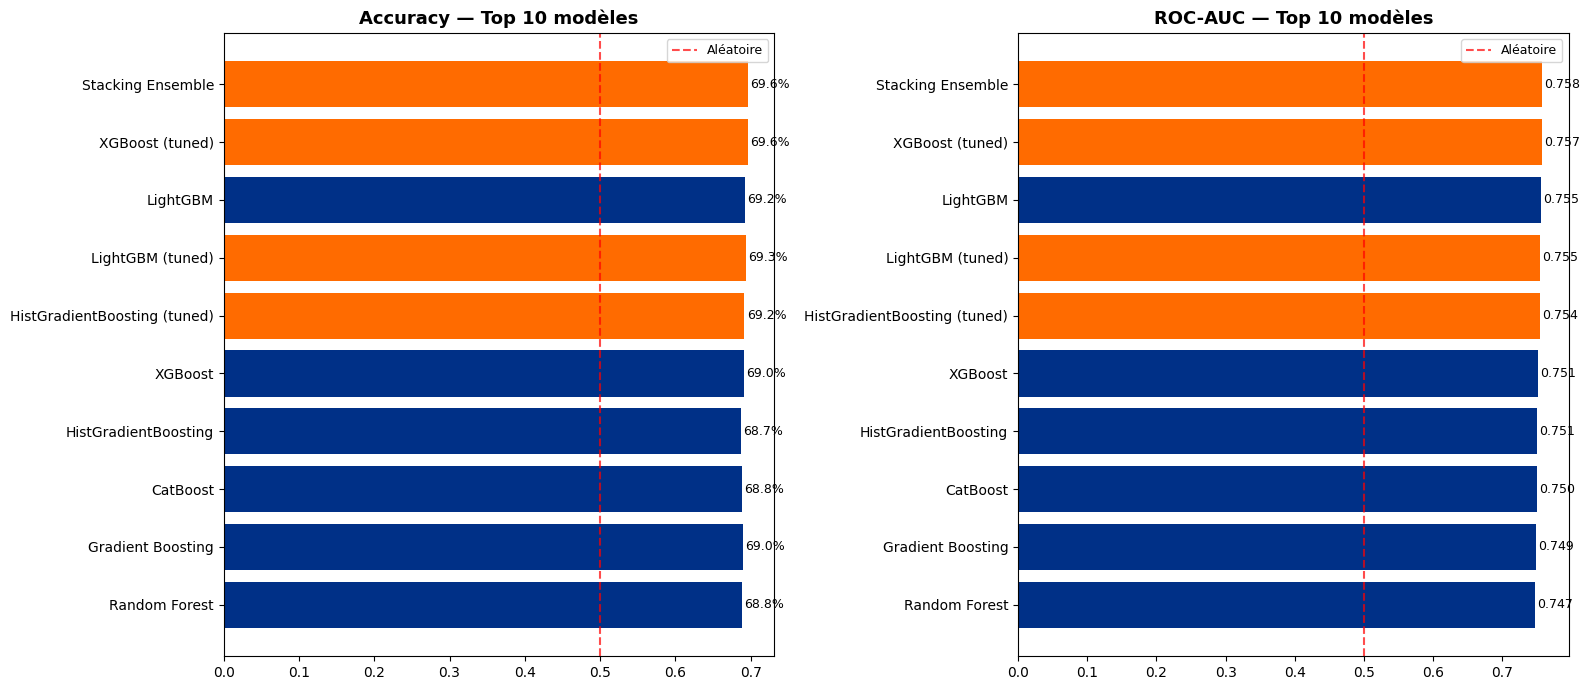

In [12]:
# Graphique comparatif final
top_final = final_df.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
palette = ['#FF6B00' if '(tuned)' in n or 'Stacking' in n else '#003087'
           for n in top_final['Modèle'][::-1]]

axes[0].barh(top_final['Modèle'][::-1], top_final['Accuracy %'][::-1] / 100, color=palette)
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Aléatoire')
axes[0].set_title('Accuracy — Top 10 modèles', fontsize=13, fontweight='bold')
for i, v in enumerate(top_final['Accuracy %'][::-1]):
    axes[0].text(v/100 + 0.003, i, f'{v:.1f}%', va='center', fontsize=9)

axes[1].barh(top_final['Modèle'][::-1], top_final['AUC'][::-1], color=palette)
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Aléatoire')
axes[1].set_title('ROC-AUC — Top 10 modèles', fontsize=13, fontweight='bold')
for i, v in enumerate(top_final['AUC'][::-1]):
    if not np.isnan(v):
        axes[1].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

for ax in axes:
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 7. Analyse des meilleurs modèles

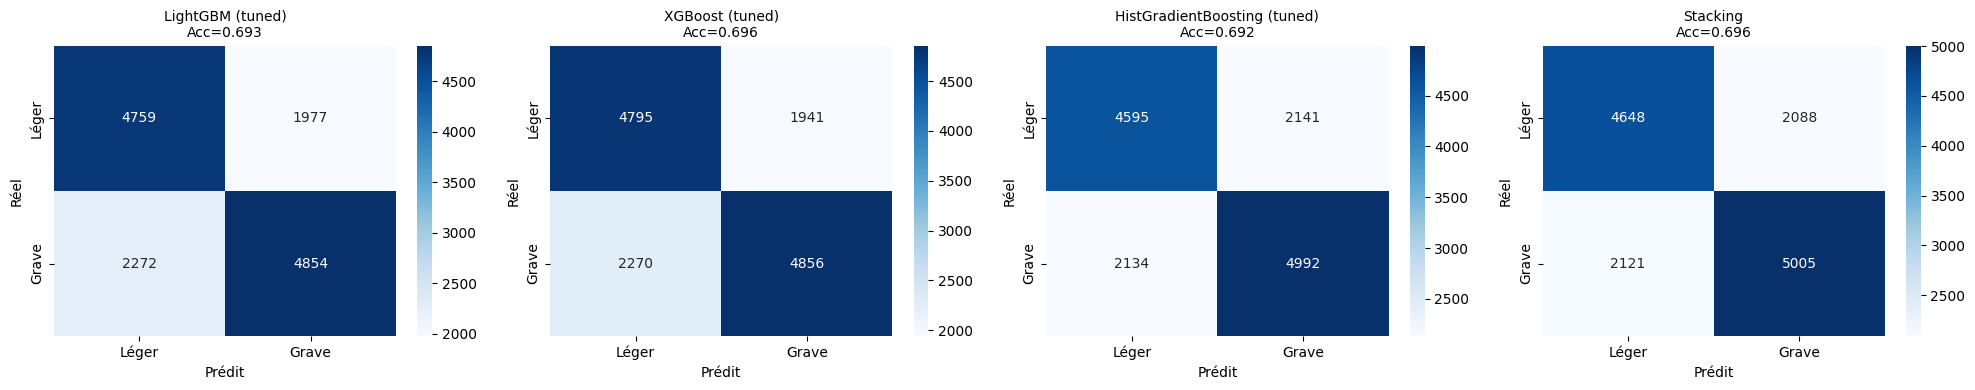

In [13]:
# Matrice de confusion des Top 3 tunés + Stacking
models_to_plot = {}
for name, mdl in list(tuned_models.items())[:3]:
    models_to_plot[f"{name} (tuned)"] = (mdl, X_test)
if stack_row and 'stack' in dir():
    models_to_plot['Stacking'] = (stack, X_test)

n = len(models_to_plot)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1: axes = [axes]

for ax, (name, (mdl, Xte)) in zip(axes, models_to_plot.items()):
    y_pred_cm = mdl.predict(Xte)
    cm = confusion_matrix(y_test, y_pred_cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Léger', 'Grave'], yticklabels=['Léger', 'Grave'])
    acc = accuracy_score(y_test, y_pred_cm)
    ax.set_title(f'{name}\nAcc={acc:.3f}', fontsize=10)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.show()

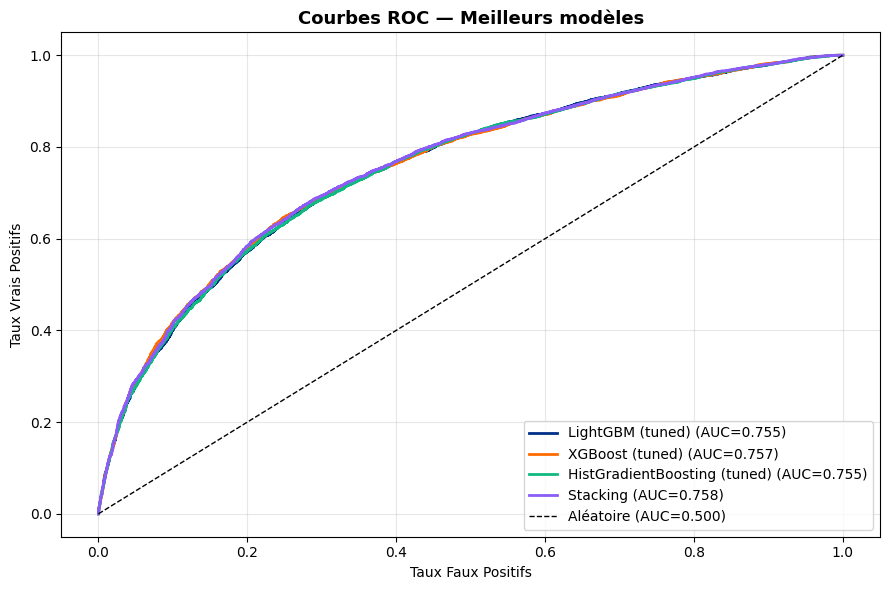

In [14]:
# Courbes ROC comparées
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(9, 6))
colors_roc = ['#003087', '#FF6B00', '#10B981', '#8B5CF6']

for (name, (mdl, Xte)), color in zip(models_to_plot.items(), colors_roc):
    if hasattr(mdl, 'predict_proba'):
        y_prob_roc = mdl.predict_proba(Xte)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob_roc)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Aléatoire (AUC=0.500)')
ax.set_xlabel('Taux Faux Positifs')
ax.set_ylabel('Taux Vrais Positifs')
ax.set_title('Courbes ROC — Meilleurs modèles', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

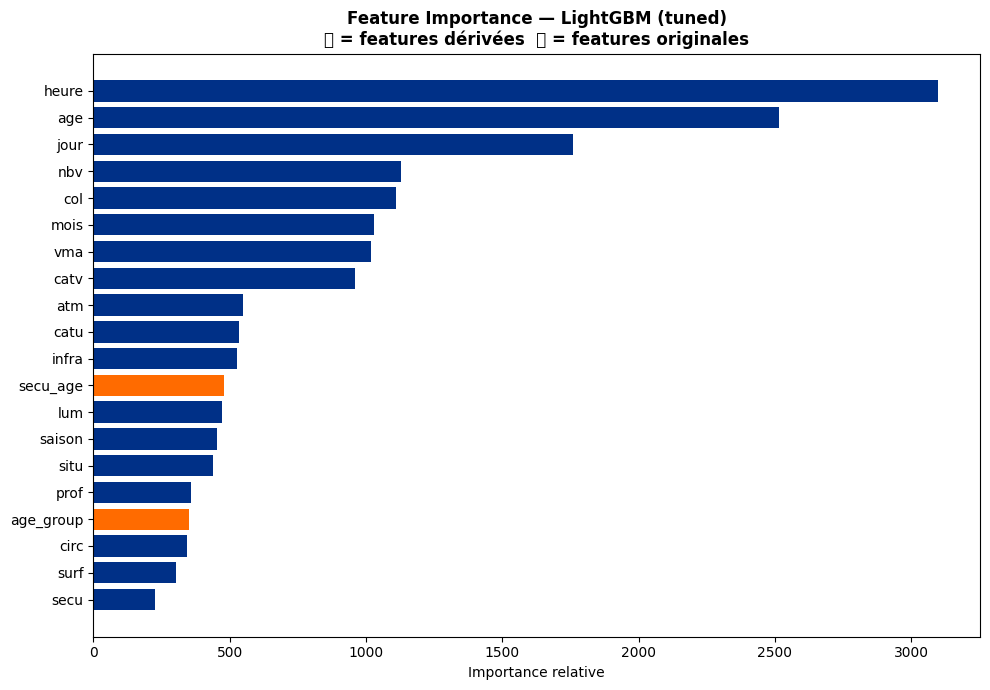

Top 10 features :
heure    3097
age      2514
jour     1761
nbv      1128
col      1109
mois     1028
vma      1018
catv      961
atm       549
catu      534


In [15]:
# Feature importance — meilleur modèle tuné
best_name = list(tuned_models.keys())[0]
best_model = tuned_models[best_name]

if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=ALL_FEAT).sort_values(ascending=False)
    top_fi = fi.head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_fi = ['#FF6B00' if f in NEW_FEATS else '#003087' for f in top_fi.index]
    ax.barh(top_fi.index[::-1], top_fi.values[::-1], color=colors_fi[::-1])
    ax.set_title(f'Feature Importance — {best_name} (tuned)\n🟠 = features dérivées  🔵 = features originales',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance relative')
    plt.tight_layout()
    plt.show()
    print("Top 10 features :")
    print(top_fi.head(10).to_string())

# 8. Conclusion & recommandation pour Vinci

In [16]:
print("=" * 65)
print("  RÉCAPITULATIF FINAL — Prédiction gravité accidents autoroutes")
print("=" * 65)
print()
print(f"Dataset  : {len(df_raw):,} usagers BAAC 2020–2024 sur autoroutes")
print(f"Features : {len(ALL_FEAT)} ({len(FEAT)} originales + {len(NEW_FEATS)} dérivées)")
print()
print("TOP 5 modèles :")
top5 = final_df.head(5)[['Modèle','Accuracy %','F1 %','AUC']]
for i, (_, r) in enumerate(top5.iterrows(), 1):
    medal = ['🥇','🥈','🥉','  4.','  5.'][i-1]
    print(f"  {medal}  {r['Modèle']:35s}  Acc={r['Accuracy %']:.1f}%  AUC={r['AUC']:.3f}")

print()
print("Features les plus prédictives (corrélation Pearson) :")
top_corr = df_raw[FEAT + ['target']].corr()['target'].drop('target').abs().sort_values(ascending=False)
for f in top_corr.head(5).index:
    print(f"  {f:12s}  r={top_corr[f]:.4f}")
print()
print("Recommandation : utiliser les 2 meilleurs modèles en production")
print("en consensus (vote de probabilités moyennes).")

  RÉCAPITULATIF FINAL — Prédiction gravité accidents autoroutes

Dataset  : 69,309 usagers BAAC 2020–2024 sur autoroutes
Features : 29 (19 originales + 10 dérivées)

TOP 5 modèles :
  🥇  Stacking Ensemble                    Acc=69.6%  AUC=0.758
  🥈  XGBoost (tuned)                      Acc=69.6%  AUC=0.757
  🥉  LightGBM                             Acc=69.2%  AUC=0.755
    4.  LightGBM (tuned)                     Acc=69.3%  AUC=0.755
    5.  HistGradientBoosting (tuned)         Acc=69.2%  AUC=0.754

Features les plus prédictives (corrélation Pearson) :
  secu          r=0.2067
  sexe          r=0.1399
  catu          r=0.0958
  col           r=0.0812
  catv          r=0.0663

Recommandation : utiliser les 2 meilleurs modèles en production
en consensus (vote de probabilités moyennes).
